# Calendar-time temporal validation tables and plots

This notebook creates manuscript-ready Table 5, Table 6, and split temporal-performance figures. Outputs are saved to `../op/calendar_time_plots/` when the notebook is run from the `notebooks/` folder. The plots use bracket-shaped group labels placed below the model labels so the bracket line does not touch or strike through text.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 180)

cwd = Path.cwd().resolve()
if cwd.name == 'notebooks':
    PROJECT_ROOT = cwd.parent
    OUTPUT_DIR = (Path('..') / 'op' / '4_calendar_time_split_perf_compare').resolve()
else:
    PROJECT_ROOT = cwd
    OUTPUT_DIR = (Path('op') / '4_calendar_time_split_perf_compare').resolve()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Current working directory:', cwd)
print('Project root:', PROJECT_ROOT)
print('Saving outputs to:', OUTPUT_DIR)
print('Relative output path from notebooks/: ../op/calendar_time_plots/')

Current working directory: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/notebooks
Project root: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0
Saving outputs to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare
Relative output path from notebooks/: ../op/calendar_time_plots/


## Table 5. Calendar-time train and temporal test split

In [2]:
table5 = pd.DataFrame({
    'Temporal split': ['Temporal training set', 'Temporal test set', 'All'],
    'Calendar period': ['2005–2018', '2019–2023', '2005–2023'],
    'Visits': [19352, 4313, 23665],
    '% of visits': [81.8, 18.2, 100.0],
    'Events': [3672, 718, 4390],
    '% of events': [83.6, 16.4, 100.0],
})

table5_display = table5.copy()
for col in ['Visits', 'Events']:
    table5_display[col] = table5_display[col].map(lambda x: f'{x:,}')
for col in ['% of visits', '% of events']:
    table5_display[col] = table5_display[col].map(lambda x: f'{x:.1f}%')

display(table5_display)
table5.to_csv(OUTPUT_DIR / 'table5_calendar_time_split_numeric.csv', index=False)
table5_display.to_csv(OUTPUT_DIR / 'table5_calendar_time_split_manuscript.csv', index=False)
caption5 = 'Table 5. Calendar-time train and temporal test split for temporal validation.'
(OUTPUT_DIR / 'table5_calendar_time_split_caption.txt').write_text(caption5 + '\\n', encoding='utf-8')
print('Saved Table 5 outputs to:', OUTPUT_DIR)

,Temporal split,Calendar period,Visits,% of visits,Events,% of events
0,Temporal training set,2005–2018,"19,352",81.8%,"3,672",83.6%
1,Temporal test set,2019–2023,"4,313",18.2%,718,16.4%
2,All,2005–2023,"23,665",100.0%,"4,390",100.0%


Saved Table 5 outputs to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare


## Table 6. Temporal test-set model performance

In [3]:
table6 = pd.DataFrame({
    'Model': [
        'Clinical-only logistic regression',
        'Clinical + LLM-enhanced medication-state logistic regression',
        'Clinical-only histogram gradient boosting',
        'Clinical + LLM-enhanced medication-state histogram gradient boosting',
    ],
    'AUROC': [0.785, 0.792, 0.806, 0.813],
    'Average precision': [0.397, 0.417, 0.459, 0.469],
    'Brier score': [0.176, 0.178, 0.165, 0.159],
    'Balanced accuracy': [0.706, 0.720, 0.725, 0.737],
})

display(table6)
table6.to_csv(OUTPUT_DIR / 'table6_calendar_time_temporal_performance_numeric.csv', index=False)
table6.to_csv(OUTPUT_DIR / 'table6_calendar_time_temporal_performance_manuscript.csv', index=False)
caption6 = 'Table 6. Temporal test-set performance using the calendar-time split.'
(OUTPUT_DIR / 'table6_calendar_time_temporal_performance_caption.txt').write_text(caption6 + '\\n', encoding='utf-8')
print('Saved Table 6 outputs to:', OUTPUT_DIR)

,Model,AUROC,Average precision,Brier score,Balanced accuracy
0,Clinical-only logistic regression,0.785,0.397,0.176,0.706
1,Clinical + LLM-enhanced medication-state logistic regression,0.792,0.417,0.178,0.720
2,Clinical-only histogram gradient boosting,0.806,0.459,0.165,0.725
3,Clinical + LLM-enhanced medication-state histogram gradient boosting,0.813,0.469,0.159,0.737


Saved Table 6 outputs to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare


## Figure 1. Calendar-time split distribution

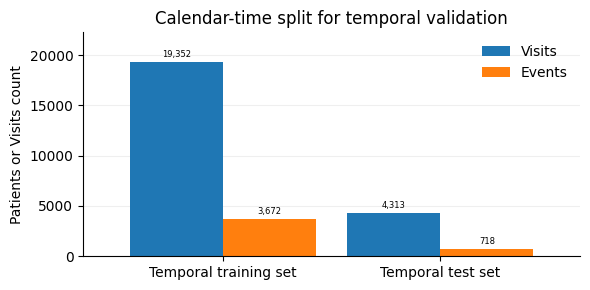

Saved Figure 1 outputs to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare


In [4]:
fig1_df = table5.loc[
    table5["Temporal split"] != "All",
    ["Temporal split", "Visits", "Events"]
].copy()

fig, ax = plt.subplots(figsize=(6.0, 3.0))

# Smaller value reduces the space between the two temporal-split groups.
group_spacing = 0.70
x = np.arange(len(fig1_df)) * group_spacing
width = 0.30

bars1 = ax.bar(
    x - width / 2,
    fig1_df["Visits"],
    width,
    label="Visits"
)

bars2 = ax.bar(
    x + width / 2,
    fig1_df["Events"],
    width,
    label="Events"
)

ax.set_xticks(x)
ax.set_xticklabels(fig1_df["Temporal split"])
ax.set_xlim(x[0] - 0.45, x[-1] + 0.45)

ax.set_ylabel("Patients or Visits count")
ax.set_title("Calendar-time split for temporal validation")

ax.grid(axis="y", alpha=0.20)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

max_y = fig1_df[["Visits", "Events"]].to_numpy().max()
ax.set_ylim(0, max_y * 1.15)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + max_y * 0.015,
            f"{int(h):,}",
            ha="center",
            va="bottom",
            fontsize=6
        )

fig.tight_layout()

for name in [
    "fig1_calendar_time_split_visits_events"
]:
    fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")

plt.show()

caption = (
    "Figure 1. Calendar-time split for temporal validation. "
    "The figure shows visit and event counts in the temporal training period "
    "and temporal test period."
)

(OUTPUT_DIR / "fig1_calendar_time_split_visits_events_caption.txt").write_text(
    caption + "\n",
    encoding="utf-8"
)

print("Saved Figure 1 outputs to:", OUTPUT_DIR)

## Split temporal-performance plots

In [5]:
def value(model_label, metric):
    return float(table6.loc[table6['Model'] == model_label, metric].iloc[0])


def make_split_performance_plot(metric_left, metric_right, title, y_min, y_max, filename_stub, note, caption):
    import textwrap
    from matplotlib.patches import Rectangle

    lr_clin = 'Clinical-only logistic regression'
    lr_llm = 'Clinical + LLM-enhanced medication-state logistic regression'
    hgb_clin = 'Clinical-only histogram gradient boosting'
    hgb_llm = 'Clinical + LLM-enhanced medication-state histogram gradient boosting'

    left_values = [
        value(lr_clin, metric_left),
        value(lr_llm, metric_left),
        value(hgb_clin, metric_left),
        value(hgb_llm, metric_left),
    ]
    right_values = [
        value(lr_clin, metric_right),
        value(lr_llm, metric_right),
        value(hgb_clin, metric_right),
        value(hgb_llm, metric_right),
    ]

    # Original bar structure is preserved:
    # each metric contains Logistic regression and HGB,
    # and each model family contains exactly two bars.
    x_positions = np.array([0.0, 1.0, 2.25, 3.25])
    x_labels = ['Logistic regression', 'HGB', 'Logistic regression', 'HGB']
    width = 0.34

    clinical_colors = ['#1f77b4', '#2ca02c', '#9467bd', '#e377c2']
    llm_colors = ['#ff7f0e', '#d62728', '#8c564b', '#7f7f7f']

    fig = plt.figure(figsize=(7.6, 5.45))
    grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 0.40], hspace=0.18)
    ax = fig.add_subplot(grid[0])
    legend_ax = fig.add_subplot(grid[1])
    legend_ax.axis('off')

    clinical_values = [left_values[0], left_values[2], right_values[0], right_values[2]]
    llm_values = [left_values[1], left_values[3], right_values[1], right_values[3]]

    for i, xpos in enumerate(x_positions):
        ax.bar(xpos - width / 2, clinical_values[i], width=width, color=clinical_colors[i], edgecolor='none')
        ax.bar(xpos + width / 2, llm_values[i], width=width, color=llm_colors[i], edgecolor='none')

        for xval, yval in [(xpos - width / 2, clinical_values[i]), (xpos + width / 2, llm_values[i])]:
            ax.text(
                xval,
                yval + (y_max - y_min) * 0.015,
                f'{yval:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=0,
            )

    ax.axvline(1.625, linestyle='--', linewidth=1.0, color='#BDBDBD', alpha=0.9)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.tick_params(axis='x', pad=8)
    ax.set_ylabel('Performance metric')
    ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=13, pad=14)
    ax.grid(axis='y', alpha=0.18)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Metric brackets and metric labels, using axis coordinates to avoid clipping.
    bracket_y = -0.120
    bracket_h = 0.030
    bracket_specs = [
        (x_positions[0] - 0.58, x_positions[1] + 0.58, metric_left, '#4C78A8'),
        (x_positions[2] - 0.58, x_positions[3] + 0.58, metric_right, '#E45756'),
    ]
    for x0, x1, metric_label, color in bracket_specs:
        ax.plot([x0, x0], [bracket_y, bracket_y + bracket_h], transform=ax.get_xaxis_transform(), color=color, linewidth=1.3, clip_on=False)
        ax.plot([x0, x1], [bracket_y, bracket_y], transform=ax.get_xaxis_transform(), color=color, linewidth=1.3, clip_on=False)
        ax.plot([x1, x1], [bracket_y, bracket_y + bracket_h], transform=ax.get_xaxis_transform(), color=color, linewidth=1.3, clip_on=False)

    # Compact legend-only correction in a separate bottom axis.
    # This prevents the legend and note from being cut off in notebook display.
    def label_swatch(ax_legend, x, y, color, text):
        ax_legend.add_patch(
            Rectangle(
                (x, y - 0.045),
                0.022,
                0.080,
                transform=ax_legend.transAxes,
                facecolor=color,
                edgecolor='none',
                clip_on=False,
            )
        )
        ax_legend.text(x + 0.030, y, text, ha='left', va='center', fontsize=8.0, transform=ax_legend.transAxes)

    def add_family_legend_block(x0, heading, clinical_lr, llm_lr, clinical_hgb, llm_hgb):
        # Metric heading plus strict four-row legend format requested by the user.
        # The first legend row is placed lower to leave more space after the metric heading.
        legend_ax.text(
            x0 + 0.18,
            0.98,
            heading,
            ha='center',
            va='top',
            fontsize=12,
            fontweight='bold',
            transform=legend_ax.transAxes,
        )

        label_swatch(legend_ax, x0, 0.74, clinical_lr, 'Logistic: clinical-only')
        label_swatch(legend_ax, x0, 0.57, llm_lr, 'Logistic: clinical + LLM medication-state')
        label_swatch(legend_ax, x0, 0.40, clinical_hgb, 'HGB: clinical-only')
        label_swatch(legend_ax, x0, 0.23, llm_hgb, 'HGB: clinical + LLM medication-state')

    add_family_legend_block(0.07, metric_left, clinical_colors[0], llm_colors[0], clinical_colors[1], llm_colors[1])
    add_family_legend_block(0.53, metric_right, clinical_colors[2], llm_colors[2], clinical_colors[3], llm_colors[3])

    legend_ax.text(
        0.5,
        -0.08,
        textwrap.fill(note, width=125),
        ha='center',
        va='top',
        fontsize=8.5,
        transform=legend_ax.transAxes,
    )

    fig.savefig(OUTPUT_DIR / f'{filename_stub}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUTPUT_DIR / f'{filename_stub}.pdf', bbox_inches='tight')
    plt.show()

    (OUTPUT_DIR / f'{filename_stub}_caption.txt').write_text(caption + '\n', encoding='utf-8')
    print('Saved:', OUTPUT_DIR / f'{filename_stub}.png')


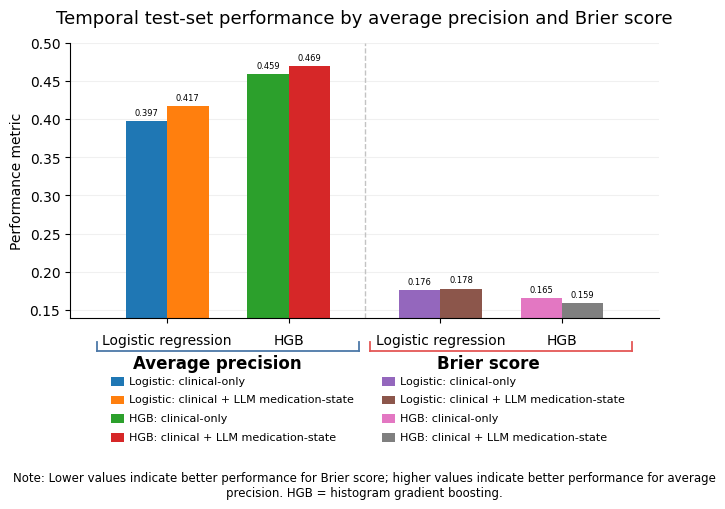

Saved: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare/fig2_calendar_time_temporal_average_precision_brier_score.png


In [6]:
caption_fig2 = (
    'Figure 2. Temporal test-set performance by average precision and Brier score using the calendar-time split. '
    'The figure compares clinical-only and clinical + LLM-enhanced medication-state models within logistic regression and HGB. '
    'Higher values indicate better performance for average precision, whereas lower values indicate better performance for Brier score. '
    'HGB denotes histogram gradient boosting.'
)
make_split_performance_plot(
    metric_left='Average precision',
    metric_right='Brier score',
    title='Temporal test-set performance by average precision and Brier score',
    y_min=0.14,
    y_max=0.50,
    filename_stub='fig2_calendar_time_temporal_average_precision_brier_score',
    note='Note: Lower values indicate better performance for Brier score; higher values indicate better performance for average precision. HGB = histogram gradient boosting.',
    caption=caption_fig2,
)

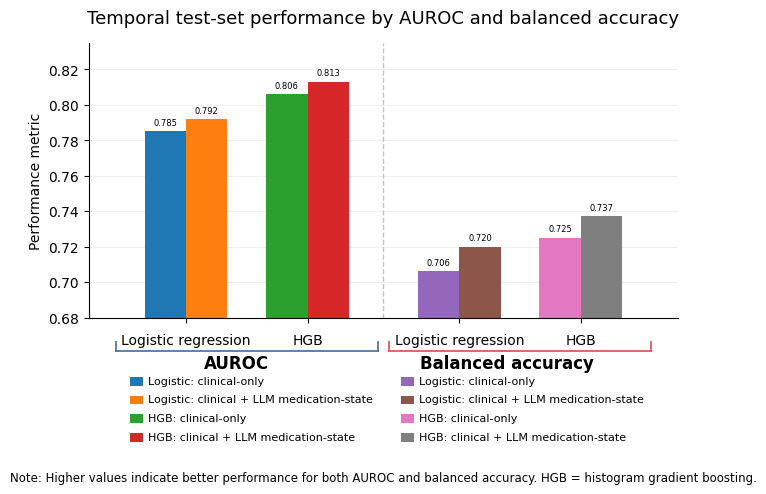

Saved: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare/fig3_calendar_time_temporal_auroc_balanced_accuracy.png


In [7]:
caption_fig3 = (
    'Figure 3. Temporal test-set performance by AUROC and balanced accuracy using the calendar-time split. '
    'The figure compares clinical-only and clinical + LLM-enhanced medication-state models within logistic regression and HGB. '
    'Higher values indicate better performance for both AUROC and balanced accuracy. '
    'HGB denotes histogram gradient boosting.'
)
make_split_performance_plot(
    metric_left='AUROC',
    metric_right='Balanced accuracy',
    title='Temporal test-set performance by AUROC and balanced accuracy',
    y_min=0.68,
    y_max=0.835,
    filename_stub='fig3_calendar_time_temporal_auroc_balanced_accuracy',
    note='Note: Higher values indicate better performance for both AUROC and balanced accuracy. HGB = histogram gradient boosting.',
    caption=caption_fig3,
)

## Incremental value summary

In [8]:
incremental = pd.DataFrame({
    'Model comparison': [
        'Logistic regression: Clinical only vs. Clinical + LLM-enhanced medication state',
        'Histogram gradient boosting: Clinical only vs. Clinical + LLM-enhanced medication state',
    ],
    'Δ AUROC': [0.792 - 0.785, 0.813 - 0.806],
    'Δ Average precision': [0.417 - 0.397, 0.469 - 0.459],
    'Δ Brier score': [0.178 - 0.176, 0.159 - 0.165],
    'Δ Balanced accuracy': [0.720 - 0.706, 0.737 - 0.725],
})
display(incremental)
incremental.to_csv(OUTPUT_DIR / 'table7_calendar_time_incremental_value_numeric.csv', index=False)
print('Saved incremental summary to:', OUTPUT_DIR / 'table7_calendar_time_incremental_value_numeric.csv')

,Model comparison,Δ AUROC,Δ Average precision,Δ Brier score,Δ Balanced accuracy
0,Logistic regression: Clinical only vs. Clinical + LLM-enhanced medication state,0.007,0.02,0.002,0.014
1,Histogram gradient boosting: Clinical only vs. Clinical + LLM-enhanced medication state,0.007,0.01,-0.006,0.012


Saved incremental summary to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare/table7_calendar_time_incremental_value_numeric.csv


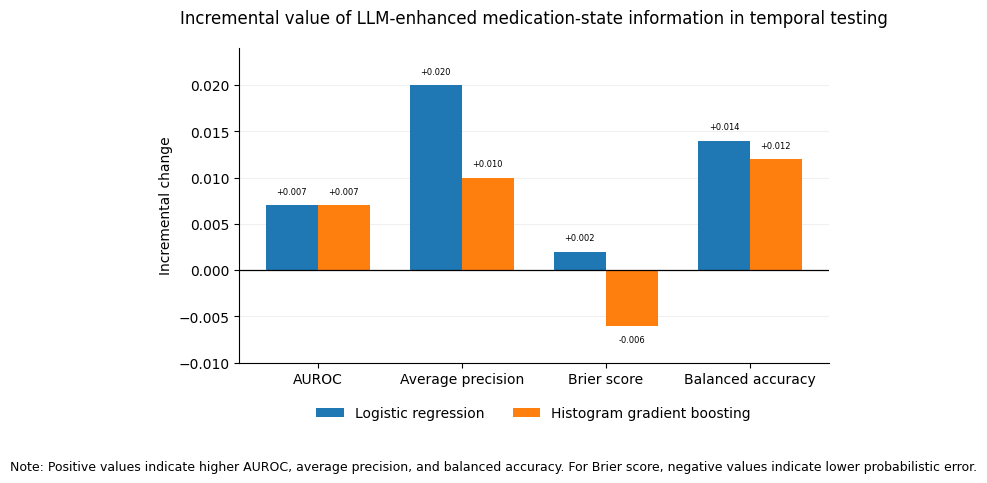

Saved incremental value figure to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/4_calendar_time_split_perf_compare/fig4_calendar_time_temporal_incremental_value.png


In [9]:
# Plot the incremental value summary.
# Values are calculated as:
# Clinical + LLM-enhanced medication-state model minus clinical-only model.

incremental_plot = incremental.copy()

incremental_plot["Model family"] = [
    "Logistic regression",
    "Histogram gradient boosting"
]

metrics = [
    "Δ AUROC",
    "Δ Average precision",
    "Δ Brier score",
    "Δ Balanced accuracy"
]

x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(7.0, 4.5))

bars_lr = ax.bar(
    x - width / 2,
    incremental_plot.loc[0, metrics].astype(float).values,
    width=width,
    label="Logistic regression"
)

bars_hgb = ax.bar(
    x + width / 2,
    incremental_plot.loc[1, metrics].astype(float).values,
    width=width,
    label="Histogram gradient boosting"
)

ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels([
    "AUROC",
    "Average precision",
    "Brier score",
    "Balanced accuracy"
])
ax.set_ylabel("Incremental change")
ax.set_title("Incremental value of LLM-enhanced medication-state information in temporal testing", pad=18)
ax.grid(axis="y", alpha=0.18)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in [bars_lr, bars_hgb]:
    for bar in bars:
        value = bar.get_height()
        va = "bottom" if value >= 0 else "top"
        offset = 0.001 if value >= 0 else -0.001
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f"{value:+.3f}",
            ha="center",
            va=va,
            fontsize=6
        )

ax.set_ylim(-0.010, 0.024)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10)
)

fig.text(
    0.5,
    -0.035,
    "Note: Positive values indicate higher AUROC, average precision, and balanced accuracy. "
    "For Brier score, negative values indicate lower probabilistic error.",
    ha="center",
    va="top",
    fontsize=9
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "fig4_calendar_time_temporal_incremental_value.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    OUTPUT_DIR / "fig4_calendar_time_temporal_incremental_value.pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved incremental value figure to:", OUTPUT_DIR / "fig4_calendar_time_temporal_incremental_value.png")